# Which Method? — Interactive Comparison

This notebook demonstrates the different prediction methods in `online-cp` side by side on synthetic data.
See the [documentation guide](https://egonmedhatten.github.io/online-cp/guide/) for the full decision tree.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Regressor Comparison

We generate a nonlinear signal and compare Ridge, Kernel Ridge, and k-NN conformal regressors.

In [2]:
# Generate nonlinear data
N = 500
X = np.random.uniform(0, 2 * np.pi, (N, 1))
y = np.sin(X[:, 0]) + 0.2 * np.random.randn(N)

In [3]:
from online_cp import (
    ConformalRidgeRegressor,
    KernelConformalRidgeRegressor,
    ConformalNearestNeighboursRegressor,
    GaussianKernel,
    IntervalWidth,
    ErrorRate,
)
from online_cp.evaluate import progressive_val

n_init = 20
X_init, y_init = X[:n_init], y[:n_init]
X_eval, y_eval = X[n_init:], y[n_init:]

models = {
    "Ridge": ConformalRidgeRegressor(a=1.0),
    "Kernel Ridge": KernelConformalRidgeRegressor(kernel=GaussianKernel(sigma=1.0), a=0.01),
    "k-NN (k=5)": ConformalNearestNeighboursRegressor(k=5),
}

results = {}
for name, model in models.items():
    model.learn_initial_training_set(X_init, y_init)
    metric = ErrorRate() + IntervalWidth()
    progressive_val(model, X_eval, y_eval, epsilon=0.1, metric=metric)
    results[name] = metric.get()
    print(f"{name:20s} | Error rate: {results[name]['ErrorRate']:.3f} | Width: {results[name]['IntervalWidth']:.3f}")

Ridge                | Error rate: 0.087 | Width: 1.982
Kernel Ridge         | Error rate: 0.085 | Width: 0.721
k-NN (k=5)           | Error rate: 0.081 | Width: 0.785


**Takeaway**: Ridge produces wide intervals on nonlinear data (it can't model the curve). Kernel Ridge and k-NN adapt to the nonlinearity and produce tighter intervals while maintaining coverage.

## 2. CPS vs Regressor

A CPS gives you the full predictive distribution. Let's compare what you get from each.

In [4]:
from online_cp import RidgePredictionMachine

# Train both on same data
X_train, y_train = X[:100], y[:100]
x_test = X[100:101]

# Regressor: gives an interval
reg = ConformalRidgeRegressor(a=1.0)
reg.learn_initial_training_set(X_train, y_train)
interval = reg.predict(x_test[0], epsilon=0.1)
print(f"Regressor interval (eps=0.1): ({interval.lower:.3f}, {interval.upper:.3f})")

# CPS: gives a full distribution
cps = RidgePredictionMachine(a=1.0)
cps.learn_initial_training_set(X_train, y_train)
cpd = cps.predict(x_test[0])

# Extract intervals at multiple levels from the CPD
for eps in [0.01, 0.05, 0.1, 0.2]:
    iv = cpd.predict_set(tau=0.5, epsilon=eps)
    print(f"  CPD interval (eps={eps}): ({iv.lower:.3f}, {iv.upper:.3f})")

Regressor interval (eps=0.1): (-0.831, 1.071)
  CPD interval (eps=0.01): (-1.014, 1.295)
  CPD interval (eps=0.05): (-0.965, 1.147)
  CPD interval (eps=0.1): (-0.840, 1.073)
  CPD interval (eps=0.2): (-0.701, 0.989)


**Takeaway**: The CPS gives you flexibility — one prediction, any significance level. The regressor is simpler if you only need one fixed $\varepsilon$.

## 3. Venn-Abers Calibrated Probabilities

Venn predictors give calibrated probabilities rather than sets.

In [5]:
from online_cp import VennAbersPredictor
from online_cp.evaluate import progressive_val_venn
from online_cp.metrics import BrierScore, LogLoss, Width

# Binary classification data
N = 500
X_cls = np.random.randn(N, 3)
y_cls = (X_cls[:, 0] + X_cls[:, 1] + 0.5 * np.random.randn(N) > 0).astype(int)

vap = VennAbersPredictor(scorer="ridge", a=1.0)
metric = BrierScore() + LogLoss() + Width()
progressive_val_venn(vap, X_cls, y_cls, metric=metric)

print(f"Brier Score: {metric.get()['BrierScore']:.4f}")
print(f"Log Loss:    {metric.get()['LogLoss']:.4f}")
print(f"Width (p1-p0): {metric.get()['Width']:.4f}  (lower = more precise)")

Brier Score: 0.1862
Log Loss:    0.2934
Width (p1-p0): 0.1066  (lower = more precise)


## 4. Martingale Change Detection Comparison

We compare Plugin (with Gaussian KDE) vs SimpleJumper on a stream with an abrupt change.

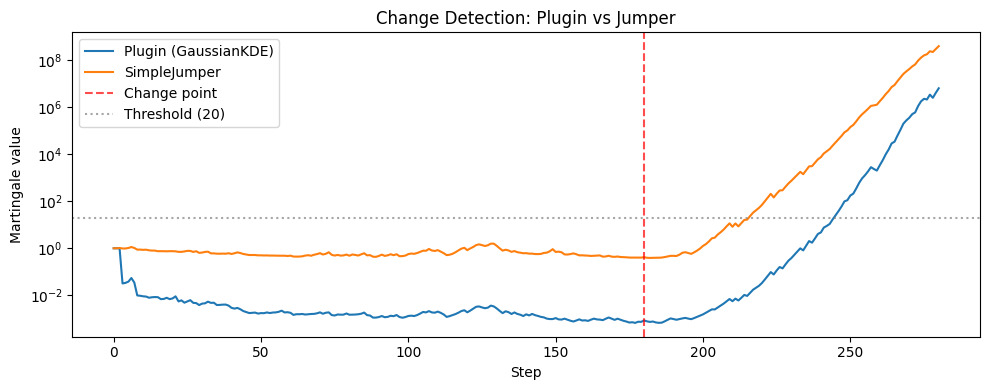

In [7]:
from online_cp import PluginMartingale, SimpleJumper, GaussianKDE
from online_cp import ConformalNearestNeighboursClassifier

# Exchangeable phase: y = sign(x1 + x2) with noise
N_null, N_alt = 200, 100
X_null = np.random.randn(N_null, 3)
y_null = (X_null[:, 0] + X_null[:, 1] + 0.5 * np.random.randn(N_null) > 0).astype(int)

# After change point: shift the mean of X so the old model is miscalibrated
X_alt = np.random.randn(N_alt, 3) + 2.0  # distribution shift
y_alt = (X_alt[:, 0] + X_alt[:, 1] + 0.5 * np.random.randn(N_alt) > 0).astype(int)

X_all = np.vstack([X_null, X_alt])
y_all = np.concatenate([y_null, y_alt])

# Compute p-values online using a conformal classifier
cp = ConformalNearestNeighboursClassifier(k=5)
n_init = 20
cp.learn_initial_training_set(X_all[:n_init], y_all[:n_init])

p_values = []
for i in range(n_init, len(y_all)):
    _, pvals = cp.predict(X_all[i], return_p_values=True)
    p_values.append(pvals[y_all[i]])  # p-value for the TRUE label
    cp.learn_one(X_all[i], y_all[i])

p_values = np.array(p_values)

# Feed p-values to martingales
plugin = PluginMartingale(betting_strategy=GaussianKDE)
jumper = SimpleJumper(J=0.01)

for p in p_values:
    plugin.update(p)
    jumper.update(p)

change_idx = N_null - n_init  # index in the p_values array

fig, ax = plt.subplots()
ax.semilogy(plugin.martingale_values, label="Plugin (GaussianKDE)")
ax.semilogy(jumper.martingale_values, label="SimpleJumper")
ax.axvline(change_idx, color='red', linestyle='--', alpha=0.7, label="Change point")
ax.axhline(20, color='gray', linestyle=':', alpha=0.7, label="Threshold (20)")
ax.set_xlabel("Step")
ax.set_ylabel("Martingale value")
ax.set_title("Change Detection: Plugin vs Jumper")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway**: Both detect the change, but they may differ in detection delay and power depending on the type of shift. The Plugin adapts its betting density to the observed p-values; the Jumper uses a fixed grid of epsilon-experts.

## 5. Mondrian CP — Label-Conditional Coverage

Standard conformal classifiers guarantee only *marginal* coverage: $P(y \in \Gamma(x)) \geq 1 - \varepsilon$.
Label-conditional Mondrian CP (ALRW2 §4.6.7) guarantees coverage **per class**: $P(y \in \Gamma(x) \mid y = c) \geq 1 - \varepsilon$ for all $c$.

In [ ]:
from online_cp import ConformalNearestNeighboursClassifier
from online_cp.mondrian import MondrianConformalClassifier

# 3-class classification
N = 600
X_m = np.random.randn(N, 3)
y_m = (X_m[:, 0] + X_m[:, 1] + X_m[:, 2] + 0.5 * np.random.randn(N))
y_m = np.digitize(y_m, bins=[-1, 1])  # 3 classes: 0, 1, 2

n_init = 30
X_init, y_init = X_m[:n_init], y_m[:n_init]
X_test, y_test = X_m[n_init:], y_m[n_init:]

# --- Standard CP (marginal validity only) ---
std_cp = ConformalNearestNeighboursClassifier(k=5)
std_cp.learn_initial_training_set(X_init, y_init)

errors_std = {c: [] for c in range(3)}
for i in range(len(y_test)):
    Gamma = std_cp.predict(X_test[i], epsilon=0.1)
    errors_std[y_test[i]].append(int(y_test[i] not in Gamma))
    std_cp.learn_one(X_test[i], y_test[i])

# --- Label-conditional Mondrian CP ---
mon_cp = MondrianConformalClassifier(
    base_model=ConformalNearestNeighboursClassifier(k=5),
    category_fn="label",
)
mon_cp.learn_initial_training_set(X_init, y_init)

errors_mon = {c: [] for c in range(3)}
for i in range(len(y_test)):
    Gamma = mon_cp.predict(X_test[i], epsilon=0.1)
    errors_mon[y_test[i]].append(int(y_test[i] not in Gamma))
    mon_cp.learn_one(X_test[i], y_test[i])

print(f"{'':18s} | {'Overall':>8s} | {'Class 0':>8s} | {'Class 1':>8s} | {'Class 2':>8s}")
print("-" * 65)
print(f"{'Standard CP':18s} | {np.mean(sum(errors_std.values(), [])):8.3f} | "
      + " | ".join(f"{np.mean(errors_std[c]):8.3f}" for c in range(3)))
print(f"{'Mondrian (label)':18s} | {np.mean(sum(errors_mon.values(), [])):8.3f} | "
      + " | ".join(f"{np.mean(errors_mon[c]):8.3f}" for c in range(3)))
print(f"\n(epsilon = 0.1; Mondrian guarantees each class individually ≤ 0.1)")


                   |  Overall |  Class 0 |  Class 1 |  Class 2
-----------------------------------------------------------------
Standard CP        |    0.082 |    0.112 |    0.065 |    0.076
Mondrian (label)   |    0.079 |    0.101 |    0.077 |    0.055

(epsilon = 0.1; Mondrian guarantees each class individually ≤ 0.1)


**Takeaway**: Standard CP may concentrate errors in one class (marginal validity only). Label-conditional Mondrian CP calibrates per class via `category_fn="label"`, ensuring each class individually satisfies the coverage guarantee.